In [1]:
from spectrumlab.peaks.analyte_peaks.intensity.transformers import (
    RegressionIntensityTransformer,
    estimate_bounds,
    process_frame,
)

from plugin.configs import PLUGIN_CONFIG
from plugin.managers.data_source_manager import DataSourceManager
from plugin.managers.data_source_manager.data_sources import XMLDataSource

In [2]:
data_source_manager = DataSourceManager(
    data_source=XMLDataSource(xml='<input>{filepath}</input>'.format(
        filepath=PLUGIN_CONFIG.filepath,
    )),
)
atom_data = data_source_manager.load()

column_id, *_ = atom_data.data.keys()
frame = atom_data.data[column_id].frame
bounds = atom_data.data[column_id].bounds
nickname = atom_data.data[column_id].nickname

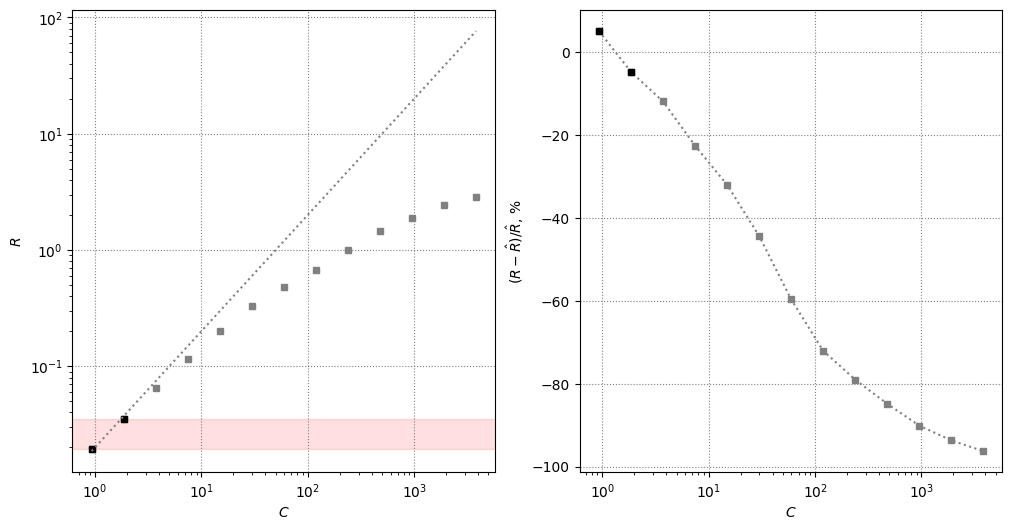

In [3]:
data = process_frame(frame)

transformer = RegressionIntensityTransformer.create(
    intensity=data['intensity'],
    concentration=data['concentration'],
    bounds=estimate_bounds(data, threshold=.05),
)
transformer.show()

In [4]:
result = frame.copy()
result = result.groupby(level=0, sort=False).mean()
result['intensity_hat'] = transformer.predict(result['intensity'])


result[['intensity', 'intensity_hat']].head(50)

,intensity,intensity_hat
probe_name,,
СО 11 ЭЛ 13,0.019548,0.019548
СО 11 ЭЛ 12,0.035439,0.035439
СО 11 ЭЛ 11,0.065574,0.074446
СО 11 ЭЛ 10,0.115395,0.149092
СО 11 ЭЛ 9,0.202714,0.298184
СО 11 ЭЛ 8,0.331832,0.596367
СО 11 ЭЛ 6,0.481519,1.192734
СО 11 ЭЛ 5,0.666889,2.385468
СО 11 ЭЛ 4,1.001048,4.771136
